## Validate entrenchment sites using raw count data
This notebook attempts to validate the findings of entrenchment of specific sites between v families or v genes using DASM using raw counts.
rates_analysis_productive_non_productive was lacking many entrenched data points because they have barely been observed in the non productive data.
To deal with this limitation, we ran a similar analysis, but instead of calculating the expected counts from the data, we will take it use thrifty to calculate, and compare to the observed counts in the productive data. 
We compare counts directly and not rates because the pcp dataset is the same, and thus has the same branch lengths and they will cancel each other out.


For productive data, observed counts (code duplicated from rates_analysis_productive_non_productive):
- Counted as mutations away from the germline amino acid for the v gene. Thus, rates are only calculated for v-gene encoded sites. 
- Calculated per v_family+site+parent_aa+child_aa, to compare to DASM.

For expected counts:
- we run thrifty on the same dataset, so branch lengths will be the same as the productive counts and counts can be compared directly.
- Thrifty gives out a rate for any substitution and a conditional substitution probability (csp). I use branch length (which can be synonymous mutation frequncy or total mutation frequency, total mutation frequency seem to work better in this case) to calculate the general substation probability from the rate, and multiply by the csp to get the substitution probability per target amino acid for every branch/pcp. I then sum over those per v_family+site+parent_aa+target_aa to get the expected counts. 


The calculation is performed on pcps and relies on previous code:
- For observed counts, site_sub_probs_df from OEPlotter is utilized - probabilities are not used of course, only the occurences of mutations on a pcp.
- For expected counts, we adapted code from dnsm-experiments-1/dnsmex/neutral_mutability.py. That code provides the mutability per a constant branch length, and here we added the option for a separate branch length calculation - synonymous mutation frequency or total mutaiton frequency.

Entrenched sites, aas and v families are loaded from _output/entrenchment_analysis made in vj_families_dasm.

Results:
- Count ratios calculated align nicely with DASM.
- Entrenched sites and substitutions also align nicely, most of them are still under purifying selection but some are closer to neutral. Need to discuss this in the paper. Not all substitutions can be validated with this approach, but most of them can.
- Synonymous mutations cluster around neutral with a more prominent purifying selection side. This could be because (1) not all synonymous mutations are truly neutral and can effect mRNA stability, codon usag and more. and (2) because when a mutation is very rare thrifty did not have a log of training data for it (or any) and so it could be oversestimating its occurence.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from types import SimpleNamespace

from utils import sort_antibody_sites, add_cdr_shading, add_germline_information, load_and_process_dnsm_data, load_and_process_dasm_data, load_entrenched_sites, GERMLINE_PATH_DICTIONARY

from dnsmex.neutral_mutability import CachedNeutralMutabilityDataset

from rates_analysis_util import (
    compare_mutation_rates_on_different_backgrounds_for_all_sites,
    add_mutation_counts_per_branch_for_branch_length,
    plot_dasm_vs_rates_comparison,
    plot_rates_pairwise_analysis,
)


In [ ]:
DATASETS = ['v1jaffe', 'v1tang']
DATASET_LABEL = '+'.join(DATASETS)

numbering_scheme = 'chothia'

BRANCH_LENGTH_METHOD = 'mutation_frequency' 
#BRANCH_LENGTH_METHOD = 'synonymous_frequency'

#BRANCH_LENGTH_SCALE_FACTOR = 1.0
BRANCH_LENGTH_SCALE_FACTOR = 1.60


# entrenchment analysis comparison parameters
dasm_compare_dataset_name = "v1rodriguez"
dasm_compare_model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


In [3]:
## load and prepare data for **observed** mutation counts

In [ ]:
## calculate observed mutation counts
## branch length method doesn't actually matter here because we are using the ratio of observed to expected counts (same pcp dataset, so same branch lengths will cancel out anyway)
## LEAF FILTERING: Leaves are excluded via remove_leaves=True in compare_mutation_rates_on_different_backgrounds_for_all_sites

output_dirs = ['_ignore/observed_counts_from_productive']
for dir in output_dirs:
    if not os.path.exists(dir):
        os.mkdir(dir)

branch_length_method = 'total_mutation_freq_branch'

output_base_path = f'_ignore/observed_counts_from_productive/observed_mutation_rates_{DATASET_LABEL}_bl_{branch_length_method}_{numbering_scheme}'

# load substitution occurences and sum counts across datasets, DNSM outputs aren't used here
all_site_sub_probs = []
all_pcp_dfs = []
pcp_offset = 0

for ds in DATASETS:
    print(f"Loading observed data for {ds}...")
    site_df, pcp_df_single = load_and_process_dnsm_data(
        model_name="dnsm_1m-v1jaffe+v1tang-joint",
        dataset_name=ds, numbering_scheme=numbering_scheme
    )
    # Offset pcp_index to avoid collisions between datasets
    site_df['pcp_index'] = site_df['pcp_index'] + pcp_offset
    pcp_df_single = pcp_df_single.copy()
    pcp_df_single.index = pcp_df_single.index + pcp_offset
    pcp_offset += len(pcp_df_single)
    all_site_sub_probs.append(site_df)
    all_pcp_dfs.append(pcp_df_single)

site_sub_probs_df_germline_total = pd.concat(all_site_sub_probs, ignore_index=True)
total_pcp_df = pd.concat(all_pcp_dfs)  # preserve offset index - it IS the pcp_index

site_sub_probs_df_germline_total = add_mutation_counts_per_branch_for_branch_length(site_sub_probs_df_germline_total)
compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline_total, output_base_path, branch_length_method=branch_length_method, remove_leaves=True, pcp_df=total_pcp_df)

observed_aa_df = pd.read_csv(f'{output_base_path}_per_aa_mutation_rates.csv', dtype={'site':str})
observed_aa_df = observed_aa_df.rename(columns={
    'mutation_acquired': 'observed_counts',
    'mutation_acquired_adjusted': 'observed_counts_adjusted',
    'mutcount_length': 'mutcount_length_observed'
}).drop(columns=['rate_mutcount', 'rate_mutcount_adjusted'])
observed_aa_df


In [ ]:
# Validate combined observed data
assert total_pcp_df.index.is_unique, "pcp_df has duplicate indices after combining datasets!"
assert len(total_pcp_df) == sum(len(df) for df in all_pcp_dfs), "pcp_df row count mismatch"
print(f"Combined observed data: {len(total_pcp_df):,} PCPs across {len(DATASETS)} datasets")
for ds, pdf in zip(DATASETS, all_pcp_dfs):
    print(f"  {ds}: {len(pdf):,} PCPs")


In [5]:
# Assert that observed counts from rates calculation file match direct computation from site_sub_probs_df
# This validates that observed counts are computed consistently with expected counts

pcp_indices_non_leaf = total_pcp_df[~total_pcp_df['child_is_leaf']].index
observed_aa_df_test = site_sub_probs_df_germline_total[
      (site_sub_probs_df_germline_total.is_germline_codon == True) &
      (site_sub_probs_df_germline_total.pcp_index.isin(pcp_indices_non_leaf)) &
      (site_sub_probs_df_germline_total.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))      
  ].groupby(['site', 'parent_aa', 'v_family', 'child_aa']).mutation.sum().reset_index()


observed_aa_df_test = observed_aa_df_test[
    (observed_aa_df_test.mutation > 0)
].rename(columns={'mutation':'observed_counts'})[
    ['v_family', 'site', 'parent_aa', 'child_aa','observed_counts']
].sort_values(['v_family', 'site', 'parent_aa', 'child_aa']).reset_index(drop=True)

observed_from_rates = observed_aa_df[
    (observed_aa_df.observed_counts > 0)
][['v_family', 'site', 'parent_aa', 'child_aa','observed_counts']].sort_values(
    ['v_family', 'site', 'parent_aa', 'child_aa']
).reset_index(drop=True)

assert observed_aa_df_test.equals(observed_from_rates), \
    "Observed counts from direct computation don't match cached file!"

In [6]:
# load thrifty neutral model **expected** mutation counts
# Updated to use new CachedNeutralMutabilityDataset from dnsm-experiments-1
# Loads each dataset separately with pcp_index offset, then combines

all_aa_neutral, all_aa_to_any_neutral = [], []
all_codon_neutral, all_codon_to_any_neutral = [], []
all_neutral_pcp_dfs = []
pcp_offset = 0

for ds in DATASETS:
    print(f"Loading expected data for {ds}...")
    neutral_ds = CachedNeutralMutabilityDataset(
        dataset_nickname=ds,
        branch_length_mode=BRANCH_LENGTH_METHOD,
        branch_length_scale_factor=BRANCH_LENGTH_SCALE_FACTOR,
        numbering_scheme=numbering_scheme,
        skip_nucleotide=True,
    )
    # Offset pcp_index to avoid collisions between datasets
    neutral_ds.pcp_df = neutral_ds.pcp_df.copy()
    neutral_ds.pcp_df.index = neutral_ds.pcp_df.index + pcp_offset
    for attr in ['aa_neutral_df', 'aa_to_any_neutral_df',
                 'codon_neutral_df', 'codon_to_any_neutral_df']:
        getattr(neutral_ds, attr)['pcp_index'] = getattr(neutral_ds, attr)['pcp_index'] + pcp_offset

    all_aa_neutral.append(neutral_ds.aa_neutral_df)
    all_aa_to_any_neutral.append(neutral_ds.aa_to_any_neutral_df)
    all_codon_neutral.append(neutral_ds.codon_neutral_df)
    all_codon_to_any_neutral.append(neutral_ds.codon_to_any_neutral_df)
    all_neutral_pcp_dfs.append(neutral_ds.pcp_df)
    pcp_offset += len(neutral_ds.pcp_df)

neutral_probabilties = SimpleNamespace(
    pcp_df=pd.concat(all_neutral_pcp_dfs),  # preserve offset index
    aa_neutral_df=pd.concat(all_aa_neutral, ignore_index=True),
    aa_to_any_neutral_df=pd.concat(all_aa_to_any_neutral, ignore_index=True),
    codon_neutral_df=pd.concat(all_codon_neutral, ignore_index=True),
    codon_to_any_neutral_df=pd.concat(all_codon_to_any_neutral, ignore_index=True),
)

# add germline information to all dataframes
neutral_probabilties.aa_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.aa_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.aa_to_any_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.aa_to_any_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.codon_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.codon_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.codon_to_any_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.codon_to_any_neutral_df, numbering_scheme=numbering_scheme)

# LEAF FILTERING for expected data: Manually filter out leaf nodes to match observed data
# (observed uses remove_leaves=True in compare_mutation_rates_on_different_backgrounds_for_all_sites)
pcp_indices_non_leaf = neutral_probabilties.pcp_df[~neutral_probabilties.pcp_df['child_is_leaf']].index
# probabilities sum to counts
expected_aa_df = neutral_probabilties.aa_neutral_df[
      (neutral_probabilties.aa_neutral_df.is_germline_codon == True) &
      (neutral_probabilties.aa_neutral_df.pcp_index.isin(pcp_indices_non_leaf))
  ].groupby(['site', 'current_aa', 'v_family', 'transition_aa']).substitution_probability.sum().reset_index()
expected_aa_df

In [ ]:
# Validate combined expected data
assert neutral_probabilties.pcp_df.index.is_unique, "Expected pcp_df has duplicate indices!"
print(f"Combined expected data: {len(neutral_probabilties.pcp_df):,} PCPs")
for ds, pdf in zip(DATASETS, all_neutral_pcp_dfs):
    print(f"  {ds}: {len(pdf):,} PCPs")
print(f"  aa_neutral_df: {len(neutral_probabilties.aa_neutral_df):,} rows")
print(f"  codon_neutral_df: {len(neutral_probabilties.codon_neutral_df):,} rows")
print(f"\nExpected AA groupby count: {len(expected_aa_df):,} unique (v_family, site, parent_aa, child_aa) groups")

<Axes: >

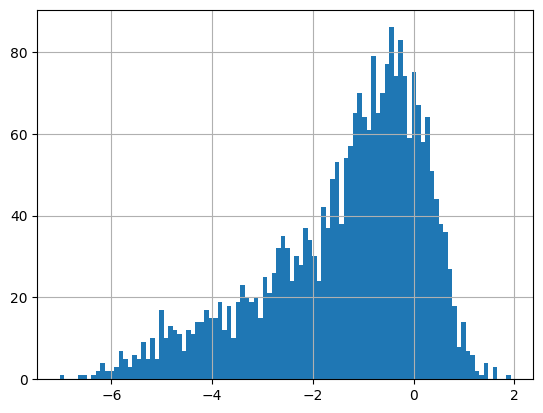

In [7]:
# merge observed and expected counts - ratio should be the selection factor.

merge_counts = pd.merge(expected_aa_df.rename(columns={'current_aa':'parent_aa', 'transition_aa':'child_aa', 'substitution_probability':'expected_counts'}), observed_aa_df, on=['v_family', 'site', 'parent_aa', 'child_aa'])

# Use adjusted counts (with pseudocount already applied)
# For expected counts from Thrifty, we add pseudocount here since Thrifty doesn't have it built in
pseudocount = 0.5
merge_counts['ratio'] = merge_counts['observed_counts_adjusted'] / (merge_counts['expected_counts'] + pseudocount)
merge_counts['log_ratio'] = np.log(merge_counts['ratio'])

merge_counts[merge_counts.expected_counts >= 5].log_ratio.hist(bins=100)

## load entrenches sites identified by DASM analysis

We separate sites into two types of evolutionarily constrained sites:
- Within v family entrenched sites
- Between v-family entrenched sites

Here we plot both types together, since we just want to make sure our entrenched sites are not edge cases with low counts.

In [8]:
# Load entrenched sites using consolidated function from utils
entrenched_sites, entrenched_sites_aas, pairwise_df_dict, SITE_COLOR_MAP, within_dfs, vs_dfs = load_entrenched_sites(numbering_scheme)

print(f"Loaded {len(entrenched_sites)} entrenched sites")
print(f"Loaded {len(entrenched_sites_aas)} entrenched site-aa pairs")
print(f"Created color mapping for {len(SITE_COLOR_MAP)} sites")

Loaded 37 entrenched sites
Loaded 83 entrenched site-aa pairs
Created color mapping for 15 sites


In [9]:
pairwise_df_dict.keys()

dict_keys(['IGHV3_vs_IGHV4', 'IGHV1_vs_IGHV4', 'IGHV1_vs_IGHV3', 'within_IGHV3', 'within_IGHV1', 'within_IGHV4'])

## Compare rate ratio to DASM

In [10]:
### compare to DASM


_, _, aa_site_subs_selection_df_germline = load_and_process_dasm_data(model_name=dasm_compare_model_name, dataset_name=dasm_compare_dataset_name, numbering_scheme=numbering_scheme)

dasm_summarized = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline.is_germline_aa == True) & (aa_site_subs_selection_df_germline.one_mutation_away == True)].groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).selection_factor.median().reset_index()


Adding one_mutation_away column (vectorized)...


In [11]:
## show unfiltered data

compare_dasm_rates = pd.merge(merge_counts, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])
compare_dasm_rates.to_csv(f'figures/rates_productive_w_thrifty_{DATASET_LABEL}_compare_dasm_rates_unfiltered.csv', index=False)

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, SITE_COLOR_MAP)
plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, SITE_COLOR_MAP)

In [12]:
# show filtered data

compare_dasm_rates = pd.merge(merge_counts, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

compare_dasm_rates = compare_dasm_rates[compare_dasm_rates.expected_counts >= 5]

plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, SITE_COLOR_MAP, 
                              savefig_prefix=f'{DATASET_LABEL}_rates_w_thrifty_', 
                              title="Comparison of Observed/Thrifty-Expected Rates Ratio vs DASM Selection Factor",
                              title_extra='(mutations expected >= 5)')

plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, SITE_COLOR_MAP, 
                             savefig_prefix=f'{DATASET_LABEL}_rates_w_thrifty_', title_extra='(mutations expected >= 5)')

## Validation: Synonymous vs Non-synonymous Mutations

Test that synonymous mutations have log count ratios centered around 0 (neutral), while non-synonymous mutations show a broader distribution with more negative values (purifying selection).

This analysis uses codon-level counts to separate synonymous from non-synonymous changes.

In [13]:
# Filter expected data to exclude leaves (to match observed):
pcp_indices_non_leaf = neutral_probabilties.pcp_df[~neutral_probabilties.pcp_df['child_is_leaf']].index
# Get codon-level expected counts from Thrifty
expected_codon_df = neutral_probabilties.codon_neutral_df[
    (neutral_probabilties.codon_neutral_df.is_germline_codon == True) & 
    (neutral_probabilties.codon_neutral_df.pcp_index.isin(pcp_indices_non_leaf))
].groupby(['site', 'current_codon', 'v_family', 'transition_codon']).substitution_probability.sum().reset_index()


expected_codon_df = expected_codon_df.rename(columns={
    'current_codon': 'parent_codon', 
    'transition_codon': 'child_codon', 
    'substitution_probability': 'expected_counts'
})

# Add parent_aa and child_aa columns
from Bio.Seq import Seq

expected_codon_df['parent_aa'] = expected_codon_df['parent_codon'].apply(
    lambda x: str(Seq(x).translate()) if len(x) == 3 else 'X'
)
expected_codon_df['child_aa'] = expected_codon_df['child_codon'].apply(
    lambda x: str(Seq(x).translate()) if len(x) == 3 else 'X'
)

expected_codon_df

,site,parent_codon,v_family,child_codon,expected_counts,parent_aa,child_aa
0,1,CAA,IGHV1,AAA,0.177246,Q,K
1,1,CAA,IGHV1,CAC,0.526227,Q,H
2,1,CAA,IGHV1,CAG,0.612552,Q,Q
3,1,CAA,IGHV1,CAT,0.491530,Q,H
4,1,CAA,IGHV1,CCA,0.404298,Q,P
...,...,...,...,...,...,...,...
10138,94,GCA,IGHV1,GCG,0.400497,A,A
10139,94,GCA,IGHV1,GCT,0.171452,A,A
10140,94,GCA,IGHV1,GGA,0.176948,A,G
10141,94,GCA,IGHV1,GTA,0.174430,A,V


In [14]:
# Load observed codon-level counts
observed_codon_df = pd.read_csv(f'{output_base_path}_per_codon_mutation_rates.csv', dtype={'site':str})
observed_codon_df = observed_codon_df.rename(
    columns={
        'mutation_acquired': 'observed_counts',
        'mutation_acquired_adjusted': 'observed_counts_adjusted'
    }
).drop(columns=['rate_mutcount', 'rate_mutcount_adjusted', 'mutcount_length'])

# Merge observed and expected codon counts
merge_codon_counts = pd.merge(
    expected_codon_df,
    observed_codon_df, 
    on=['v_family', 'site', 'parent_codon', 'child_codon', 'parent_aa', 'child_aa'],
    how='inner'
)

# Use adjusted counts (with pseudocount already applied to observed)
# For expected counts from Thrifty, we add pseudocount here since Thrifty doesn't have it built in
pseudocount = 0.5
merge_codon_counts['ratio'] = merge_codon_counts['observed_counts_adjusted'] / (merge_codon_counts['expected_counts'] + pseudocount)
merge_codon_counts['log_ratio'] = np.log(merge_codon_counts['ratio'])

merge_codon_counts

,site,parent_codon,v_family,child_codon,expected_counts,parent_aa,child_aa,observed_counts,observed_counts_adjusted,ratio,log_ratio
0,1,CAA,IGHV1,AAA,0.177246,Q,K,0,0.5,0.738284,-0.303427
1,1,CAA,IGHV1,CAC,0.526227,Q,H,0,0.5,0.487222,-0.719036
2,1,CAA,IGHV1,CAG,0.612552,Q,Q,0,0.5,0.449417,-0.799804
3,1,CAA,IGHV1,CAT,0.491530,Q,H,0,0.5,0.504271,-0.684641
4,1,CAA,IGHV1,CCA,0.404298,Q,P,0,0.5,0.552915,-0.592551
...,...,...,...,...,...,...,...,...,...,...,...
6151,94,GCA,IGHV1,GCG,0.400497,A,A,1,1.5,1.665747,0.510274
6152,94,GCA,IGHV1,GCT,0.171452,A,A,1,1.5,2.233964,0.803778
6153,94,GCA,IGHV1,GGA,0.176948,A,G,0,0.5,0.738609,-0.302987
6154,94,GCA,IGHV1,GTA,0.174430,A,V,0,0.5,0.741367,-0.299260


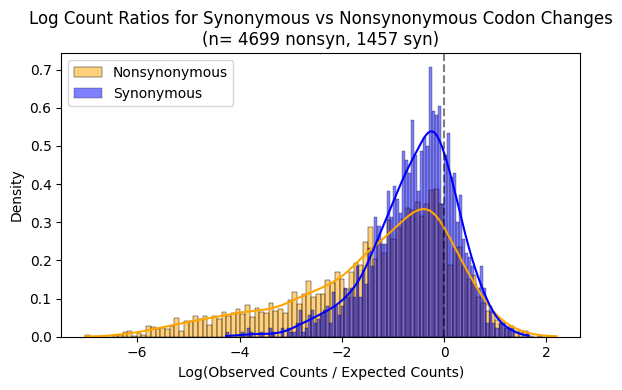

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

# Filter data
nonsynonymous = merge_codon_counts[
    merge_codon_counts.parent_aa != merge_codon_counts.child_aa
].log_ratio

synonymous = merge_codon_counts[
    merge_codon_counts.parent_aa == merge_codon_counts.child_aa
].log_ratio

sns.histplot(nonsynonymous, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100, color='orange')
sns.histplot(synonymous, ax=ax, label='Synonymous', kde=True, stat='density', alpha=0.5, bins=100, color='blue')

ax.legend()
ax.set_xlabel('Log(Observed Counts / Expected Counts)')
ax.set_title('Log Count Ratios for Synonymous vs Nonsynonymous Codon Changes\n(n= {} nonsyn, {} syn)'.format(len(nonsynonymous), len(synonymous)))
ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Neutral (ratio=1)')
plt.tight_layout()
plt.show()

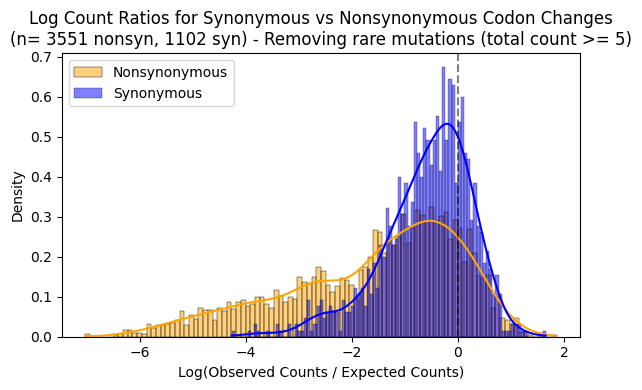


Summary statistics (filtered data):
Synonymous mutations - Mean log ratio: -0.587, Median: -0.452
Nonsynonymous mutations - Mean log ratio: -1.579, Median: -1.209


In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

# Filter data - remove rare mutations
min_count_threshold = 5

nonsynonymous = merge_codon_counts[
    (merge_codon_counts.parent_aa != merge_codon_counts.child_aa) &
    (merge_codon_counts['expected_counts'] >= min_count_threshold)
].log_ratio

synonymous = merge_codon_counts[
    (merge_codon_counts.parent_aa == merge_codon_counts.child_aa) &
    (merge_codon_counts['expected_counts'] >= min_count_threshold)
].log_ratio

sns.histplot(nonsynonymous, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100, color='orange')
sns.histplot(synonymous, ax=ax, label='Synonymous', kde=True, stat='density', alpha=0.5, bins=100, color='blue')

ax.legend()
ax.set_xlabel('Log(Observed Counts / Expected Counts)')
ax.set_title('Log Count Ratios for Synonymous vs Nonsynonymous Codon Changes\n(n= {} nonsyn, {} syn) - Removing rare mutations (total count >= {})'.format(
    len(nonsynonymous), len(synonymous), min_count_threshold))
ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Neutral (ratio=1)')
plt.tight_layout()
plt.show()

print(f"\nSummary statistics (filtered data):")
print(f"Synonymous mutations - Mean log ratio: {synonymous.mean():.3f}, Median: {synonymous.median():.3f}")
print(f"Nonsynonymous mutations - Mean log ratio: {nonsynonymous.mean():.3f}, Median: {nonsynonymous.median():.3f}")

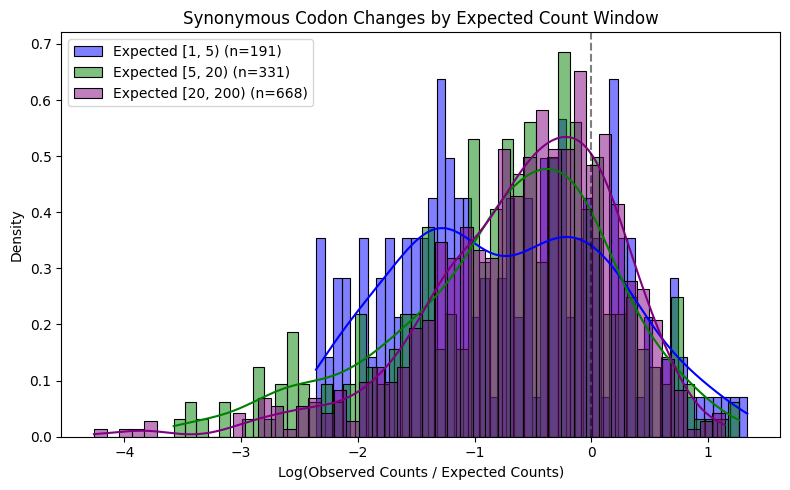

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

# Define non-overlapping windows
windows = [(1, 5), (5, 20), (20, 200)]
colors = ['blue', 'green', 'purple']

for (low, high), color in zip(windows, colors):
    data = merge_codon_counts[
        (merge_codon_counts.parent_aa == merge_codon_counts.child_aa) &
        (merge_codon_counts['expected_counts'] >= low) &
        (merge_codon_counts['expected_counts'] < high)
    ].log_ratio
    
    sns.histplot(data, ax=ax, label=f'Expected [{low}, {high}) (n={len(data)})', 
                 kde=True, stat='density', alpha=0.5, bins=50, color=color)

ax.legend()
ax.set_xlabel('Log(Observed Counts / Expected Counts)')
ax.set_title('Synonymous Codon Changes by Expected Count Window')
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Attempt at finding entrenchment directly from counts and rates data
This was a thought I had about flipping the order of the paper: starting from findng entrenchment in counts based approach, finding some but motivating using DASM as many sites don't have enough data.
Then moving onto the DASM entrenchment analysis. 

Currently this isn't used but leaving here for now.

In [18]:
germline_codons_df = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})


temp_df = pd.merge(merge_counts[merge_counts['expected_counts'] >= 5], 
         merge_counts[merge_counts['expected_counts'] >= 5].rename(columns={'parent_aa': 'child_aa','child_aa': 'parent_aa'}),
            on=['site', 'parent_aa', 'child_aa'],
            suffixes=('_original', '_reversed')
            )

temp_df

,site,parent_aa,v_family_original,child_aa,expected_counts_original,mutcount_length_observed_original,observed_counts_original,observed_counts_adjusted_original,ratio_original,log_ratio_original,v_family_reversed,expected_counts_reversed,mutcount_length_observed_reversed,observed_counts_reversed,observed_counts_adjusted_reversed,ratio_reversed,log_ratio_reversed
0,1,E,IGHV3,Q,163.791796,498.683864,28,28.5,0.173472,-1.751740,IGHV1,16.888143,109.241070,4,4.5,0.258797,-1.351711
1,1,E,IGHV3,Q,163.791796,498.683864,28,28.5,0.173472,-1.751740,IGHV3,14.746046,102.063711,8,8.5,0.557522,-0.584254
2,1,E,IGHV3,Q,163.791796,498.683864,28,28.5,0.173472,-1.751740,IGHV4,34.731722,213.206316,7,7.5,0.212876,-1.547044
3,1,Q,IGHV1,E,16.888143,109.241070,4,4.5,0.258797,-1.351711,IGHV3,163.791796,498.683864,28,28.5,0.173472,-1.751740
4,1,Q,IGHV3,E,14.746046,102.063711,8,8.5,0.557522,-0.584254,IGHV3,163.791796,498.683864,28,28.5,0.173472,-1.751740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,94,R,IGHV4,T,66.996394,166.806461,42,42.5,0.629663,-0.462570,IGHV3,10.407476,28.142663,7,7.5,0.687602,-0.374545
748,94,T,IGHV3,K,7.931423,28.142663,7,7.5,0.889530,-0.117063,IGHV3,60.639399,123.665665,13,13.5,0.220807,-1.510467
749,94,T,IGHV3,R,10.407476,28.142663,7,7.5,0.687602,-0.374545,IGHV1,33.751247,81.280390,17,17.5,0.510930,-0.671522
750,94,T,IGHV3,R,10.407476,28.142663,7,7.5,0.687602,-0.374545,IGHV3,123.974324,279.782267,80,80.5,0.646720,-0.435842


<Axes: xlabel='site', ylabel='log_ratio_sum'>

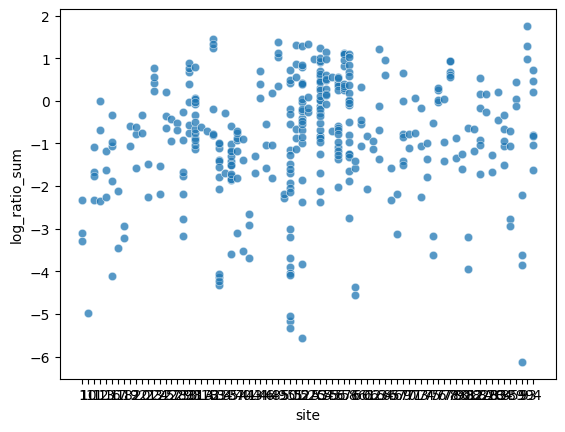

In [19]:
temp_df['log_ratio_sum'] = temp_df['log_ratio_original'] + temp_df['log_ratio_reversed']

sns.scatterplot(data=temp_df, x='site', y='log_ratio_sum', alpha=0.5)

In [20]:
# Add this import at the top if not already present:
# from utils import sort_antibody_sites, add_cdr_shading

def compare_rates_within_vfamily_with_distribution(rates_aa_summarized, germline_codons_df, 
                                                    v_family, numbering_scheme='chothia',
                                                    min_expected_counts=5, threshold=-1,
                                                    figsize=(20, 6)):
    '''
    Compare log ratios within a v_family at sites that have more than one possible aa.
    Uses observed/expected count ratios instead of DASM selection factors.
    
    Parameters:
    -----------
    rates_aa_summarized : pd.DataFrame
        DataFrame with columns: v_family, site, parent_aa, child_aa, log_ratio,
        expected_counts (and optionally one_mutation_away)
    germline_codons_df : pd.DataFrame
        Germline codon data for amino acid distribution plot
    v_family : str
        V family to analyze (e.g., 'IGHV3')
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    min_expected_counts : int
        Minimum expected mutation counts to include a substitution (default: 5)
    threshold : float
        Threshold for identifying entrenched sites (default: -1)
    figsize : tuple
        Figure size
        
    Returns:
    --------
    compare_df : DataFrame with comparison results
    fig : matplotlib figure
    (ax1, ax2) : tuple of axes
    '''
    # Filter rates data for this v_family
    rates_filtered = rates_aa_summarized[rates_aa_summarized.v_family == v_family].copy()
    
    # Apply minimum expected counts filter
    if min_expected_counts > 0:
        if 'mutation_acquired_expected' in rates_filtered.columns:
            rates_filtered = rates_filtered[rates_filtered.mutation_acquired_expected >= min_expected_counts]
        elif 'expected_counts' in rates_filtered.columns:
            rates_filtered = rates_filtered[rates_filtered.expected_counts >= min_expected_counts]
    
    # # Filter for one_mutation_away if column exists
    # if 'one_mutation_away' in rates_filtered.columns:
    #     rates_filtered = rates_filtered[rates_filtered.one_mutation_away == True]
    
    # Create pairwise comparison (A->B and B->A)
    rates1 = rates_filtered[['site', 'parent_aa', 'child_aa', 'log_ratio']].copy()
    rates1 = rates1.rename(columns={
        'parent_aa': 'parent_aa_1_and_target_aa_2',
        'child_aa': 'parent_aa_2_and_target_aa_1',
        'log_ratio': 'log_ratio_1'
    })
    
    rates2 = rates_filtered[['site', 'parent_aa', 'child_aa', 'log_ratio']].copy()
    rates2 = rates2.rename(columns={
        'parent_aa': 'parent_aa_2_and_target_aa_1',
        'child_aa': 'parent_aa_1_and_target_aa_2',
        'log_ratio': 'log_ratio_2'
    })
    
    compare_df = pd.merge(rates1, rates2, 
                          on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1'],
                          how='inner')
    
    compare_df['log_ratio_sum'] = compare_df['log_ratio_1'] + compare_df['log_ratio_2']
    compare_df['are_both_below_threshold'] = (
        (compare_df['log_ratio_1'] < threshold) & 
        (compare_df['log_ratio_2'] < threshold)
    )
    
    # Get data for amino acid distribution
    family_data = germline_codons_df[germline_codons_df.v_family == v_family].copy()
    
    # Get all sites and sort them properly
    all_sites_with_data = sorted(set(family_data['site'].unique()))
    sorted_sites = sort_antibody_sites(all_sites_with_data)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    if len(sorted_sites) == 0:
        print(f"Warning: No data found for {v_family}")
        return compare_df, None, None
    
    # Create amino acid color palette
    all_amino_acids = sorted(family_data['amino_acid'].unique())
    PALETTE_AA = dict(zip(all_amino_acids, sns.color_palette('tab20', len(all_amino_acids))))
    
    # ===== CREATE COMBINED PLOT =====
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 0.5], 'hspace': 0.02})
    
    # ===== TOP PLOT: SCATTER PLOT =====
    add_cdr_shading(ax1, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Plot points
    for is_below, color, label in [(False, 'grey', f'Not both < {threshold}'), 
                                    (True, 'red', f'Both < {threshold}')]:
        subset = compare_df[compare_df['are_both_below_threshold'] == is_below]
        subset_x = [site_to_position.get(site, -1) for site in subset['site']]
        valid_mask = [x >= 0 for x in subset_x]
        subset_x = [x for x, v in zip(subset_x, valid_mask) if v]
        subset_y = subset['log_ratio_sum'].values[[i for i, v in enumerate(valid_mask) if v]]
        ax1.scatter(subset_x, subset_y, alpha=0.7, label=label, c=color, s=50)
    
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1.axhline(y=2*threshold, color='red', linestyle=':', alpha=0.5)
    ax1.set_ylabel('Sum of Log Ratios\n(original + reversed)', fontsize=11)
    ax1.set_title(f'Log Ratio Sum Comparison and Germline Amino Acid Distribution in {v_family}\n(min expected counts >= {min_expected_counts})', fontsize=13)
    ax1.grid(True, alpha=0.4, linewidth=0.8)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax1.set_xticklabels([])
    
    # ===== BOTTOM PLOT: AMINO ACID DISTRIBUTION =====
    add_cdr_shading(ax2, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Calculate percentages for family at specific sites
    site_aa_counts = {}
    for aa in all_amino_acids:
        aa_data = family_data[family_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        site_aa_counts[aa] = site_counts
    
    site_total = family_data['v_gene'].nunique()
    
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom = 0
        
        for aa in all_amino_acids:
            count = site_aa_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site_pos, percentage, bottom=bottom, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'Germline Amino Acid\nDistribution', fontsize=11)
    ax2.set_ylim(0, 100)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=PALETTE_AA[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, bbox_to_anchor=(1.01, 1.5), loc='upper left', 
              title='Amino Acids', fontsize=8, ncol=1)
    
    # Set x-axis for both plots
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax2.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax1.set_xticks(range(len(sorted_sites)))
    ax2.set_xticks(range(len(sorted_sites)))
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site Position', fontsize=12)
    ax2.set_xticklabels(sorted_sites, rotation=90, fontsize=8)
    
    plt.tight_layout()
    plt.show()

    return compare_df, fig, (ax1, ax2)


def compare_rates_between_vfamilies_with_distribution(rates_aa_summarized, germline_codons_df, 
                                                       v_family1, v_family2, numbering_scheme='chothia',
                                                       min_expected_counts=5, threshold=-1,
                                                       figsize=(20, 6)):
    '''
    Compare log ratios between two v_families at sites with different germline amino acids.
    Uses observed/expected count ratios instead of DASM selection factors.
    
    Parameters:
    -----------
    rates_aa_summarized : pd.DataFrame
        DataFrame with columns: v_family, site, parent_aa, child_aa, log_ratio,
        expected_counts (and optionally one_mutation_away)
    germline_codons_df : pd.DataFrame
        Germline codon data for amino acid distribution plot
    v_family1, v_family2 : str
        V families to compare (e.g., 'IGHV1', 'IGHV3')
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    min_expected_counts : int
        Minimum expected mutation counts to include a substitution (default: 5)
    threshold : float
        Threshold for identifying entrenched sites (default: -1)
    figsize : tuple
        Figure size
        
    Returns:
    --------
    compare_df : DataFrame with comparison results
    fig : matplotlib figure
    (ax1, ax2) : tuple of axes
    '''
    # Filter rates data for each v_family
    rates1 = rates_aa_summarized[rates_aa_summarized.v_family == v_family1].copy()
    rates2 = rates_aa_summarized[rates_aa_summarized.v_family == v_family2].copy()
    
    # Apply minimum expected counts filter
    if min_expected_counts > 0:
        count_col = 'mutation_acquired_expected' if 'mutation_acquired_expected' in rates1.columns else 'expected_counts'
        if count_col in rates1.columns:
            rates1 = rates1[rates1[count_col] >= min_expected_counts]
            rates2 = rates2[rates2[count_col] >= min_expected_counts]
    
    # # Filter for one_mutation_away if column exists
    # if 'one_mutation_away' in rates1.columns:
    #     rates1 = rates1[rates1.one_mutation_away == True]
    #     rates2 = rates2[rates2.one_mutation_away == True]
    
    # Rename columns for merging
    rates1 = rates1[['site', 'parent_aa', 'child_aa', 'log_ratio']].copy()
    rates1 = rates1.rename(columns={
        'parent_aa': 'parent_aa_1_and_target_aa_2',
        'child_aa': 'parent_aa_2_and_target_aa_1',
        'log_ratio': 'log_ratio_1'
    })
    rates1['v_family_1'] = v_family1
    
    rates2 = rates2[['site', 'parent_aa', 'child_aa', 'log_ratio']].copy()
    rates2 = rates2.rename(columns={
        'parent_aa': 'parent_aa_2_and_target_aa_1',
        'child_aa': 'parent_aa_1_and_target_aa_2',
        'log_ratio': 'log_ratio_2'
    })
    rates2['v_family_2'] = v_family2
    
    # Merge: find sites where v_family1 has AA1->AA2 and v_family2 has AA2->AA1
    compare_df = pd.merge(rates1, rates2, 
                          on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1'],
                          how='inner')
    
    compare_df['log_ratio_sum'] = compare_df['log_ratio_1'] + compare_df['log_ratio_2']
    compare_df['are_both_below_threshold'] = (
        (compare_df['log_ratio_1'] < threshold) & 
        (compare_df['log_ratio_2'] < threshold)
    )
    
    # Get data for amino acid distribution
    family1_data = germline_codons_df[germline_codons_df.v_family == v_family1].copy()
    family2_data = germline_codons_df[germline_codons_df.v_family == v_family2].copy()
    
    # Get all sites and sort them properly
    all_sites_with_data = sorted(set(family1_data['site'].unique()) | set(family2_data['site'].unique()))
    sorted_sites = sort_antibody_sites(all_sites_with_data)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    if len(sorted_sites) == 0:
        print(f"Warning: No data found for {v_family1} or {v_family2}")
        return compare_df, None, None
    
    # Create amino acid color palette
    all_amino_acids = sorted(set(family1_data['amino_acid'].unique()) | set(family2_data['amino_acid'].unique()))
    PALETTE_AA = dict(zip(all_amino_acids, sns.color_palette('tab20', len(all_amino_acids))))
    
    # ===== CREATE COMBINED PLOT =====
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # ===== TOP PLOT: SCATTER PLOT =====
    add_cdr_shading(ax1, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Plot points
    for is_below, color, label in [(False, 'grey', f'Not both < {threshold}'), 
                                    (True, 'red', f'Both < {threshold}')]:
        subset = compare_df[compare_df['are_both_below_threshold'] == is_below]
        subset_x = [site_to_position.get(site, -1) for site in subset['site']]
        valid_mask = [x >= 0 for x in subset_x]
        subset_x = [x for x, v in zip(subset_x, valid_mask) if v]
        subset_y = subset['log_ratio_sum'].values[[i for i, v in enumerate(valid_mask) if v]]
        ax1.scatter(subset_x, subset_y, alpha=0.7, label=label, c=color, s=50)
    
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1.axhline(y=2*threshold, color='red', linestyle=':', alpha=0.5)
    ax1.set_ylabel('Sum of Log Ratios\n(original + reversed)', fontsize=11)
    ax1.set_title(f'Log Ratio Sum: {v_family1} vs {v_family2}\n(min expected counts >= {min_expected_counts})', fontsize=13)
    ax1.grid(True, alpha=0.4, linewidth=0.8)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax1.set_xticklabels([])
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION =====
    add_cdr_shading(ax2, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Calculate counts for each amino acid at each site
    family1_site_counts = {}
    family2_site_counts = {}
    for aa in all_amino_acids:
        aa_data1 = family1_data[family1_data['amino_acid'] == aa]
        family1_site_counts[aa] = aa_data1['site'].value_counts()
        aa_data2 = family2_data[family2_data['amino_acid'] == aa]
        family2_site_counts[aa] = aa_data2['site'].value_counts()
    
    site_total1 = family1_data['v_gene'].nunique()
    site_total2 = family2_data['v_gene'].nunique()
    
    # Plot family1 above x-axis (positive values)
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom1 = 0
        for aa in all_amino_acids:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total1 > 0:
                percentage = (count / site_total1) * 100
                ax2.bar(site_pos, percentage, bottom=bottom1, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Plot family2 below x-axis (negative values)
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom2 = 0
        for aa in all_amino_acids:
            count = family2_site_counts[aa].get(site, 0)
            if count > 0 and site_total2 > 0:
                percentage = -(count / site_total2) * 100
                ax2.bar(site_pos, percentage, bottom=bottom2, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom2 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'Germline Amino Acid\nDistribution', fontsize=11)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    
    # Add family labels
    ax2.text(len(sorted_sites) + 0.5, 50, v_family1, fontsize=10, va='center')
    ax2.text(len(sorted_sites) + 0.5, -50, v_family2, fontsize=10, va='center')
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=PALETTE_AA[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, bbox_to_anchor=(1.01, 1.5), loc='upper left', 
              title='Amino Acids', fontsize=8, ncol=1)
    
    # Set x-axis for both plots
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax2.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax1.set_xticks(range(len(sorted_sites)))
    ax2.set_xticks(range(len(sorted_sites)))
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site Position', fontsize=12)
    ax2.set_xticklabels(sorted_sites, rotation=90, fontsize=8)
    
    plt.tight_layout()
    plt.show()

    return compare_df, fig, (ax1, ax2)

/loc/scratch/49383474/ipykernel_36236/1421534784.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


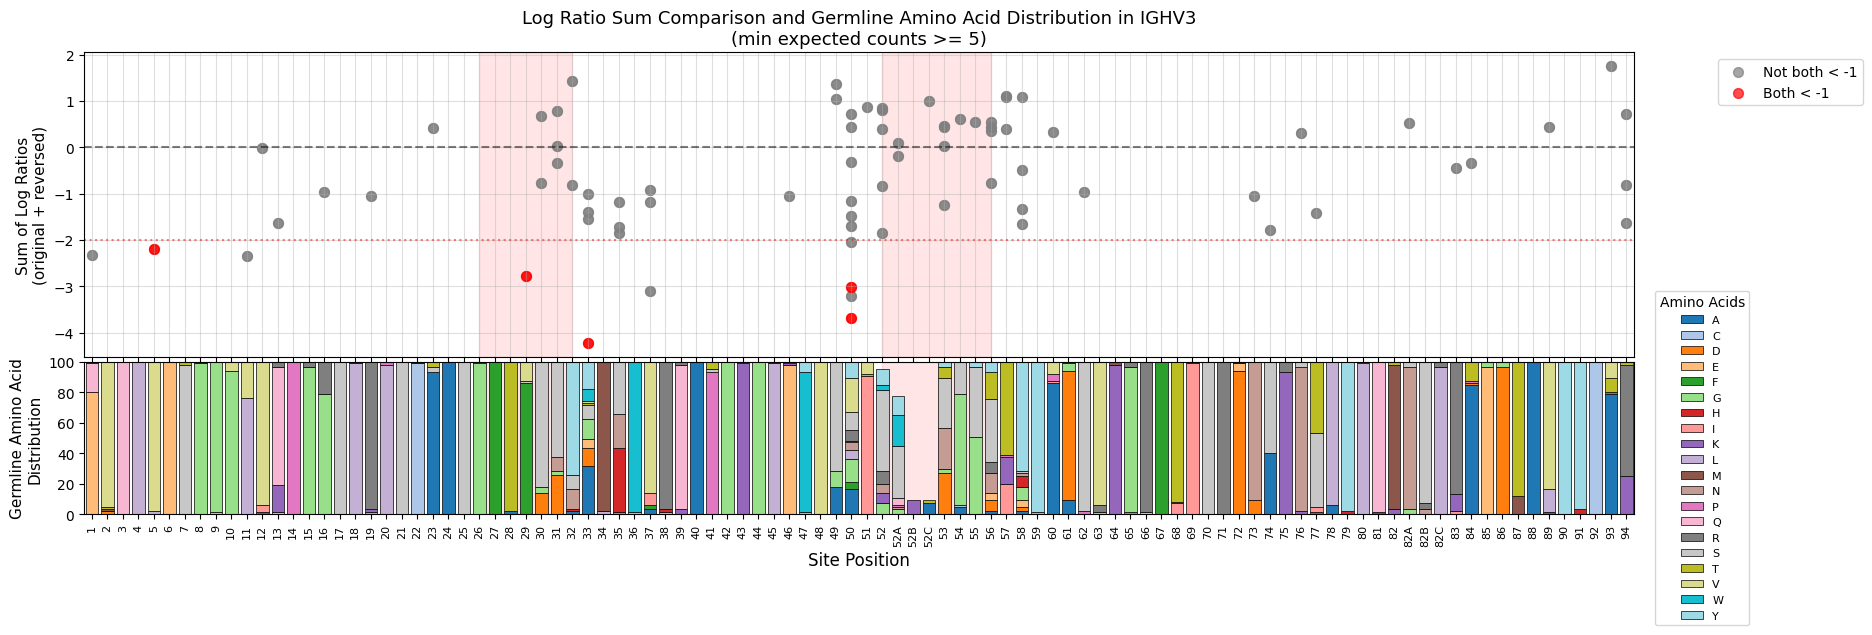

/loc/scratch/49383474/ipykernel_36236/1421534784.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


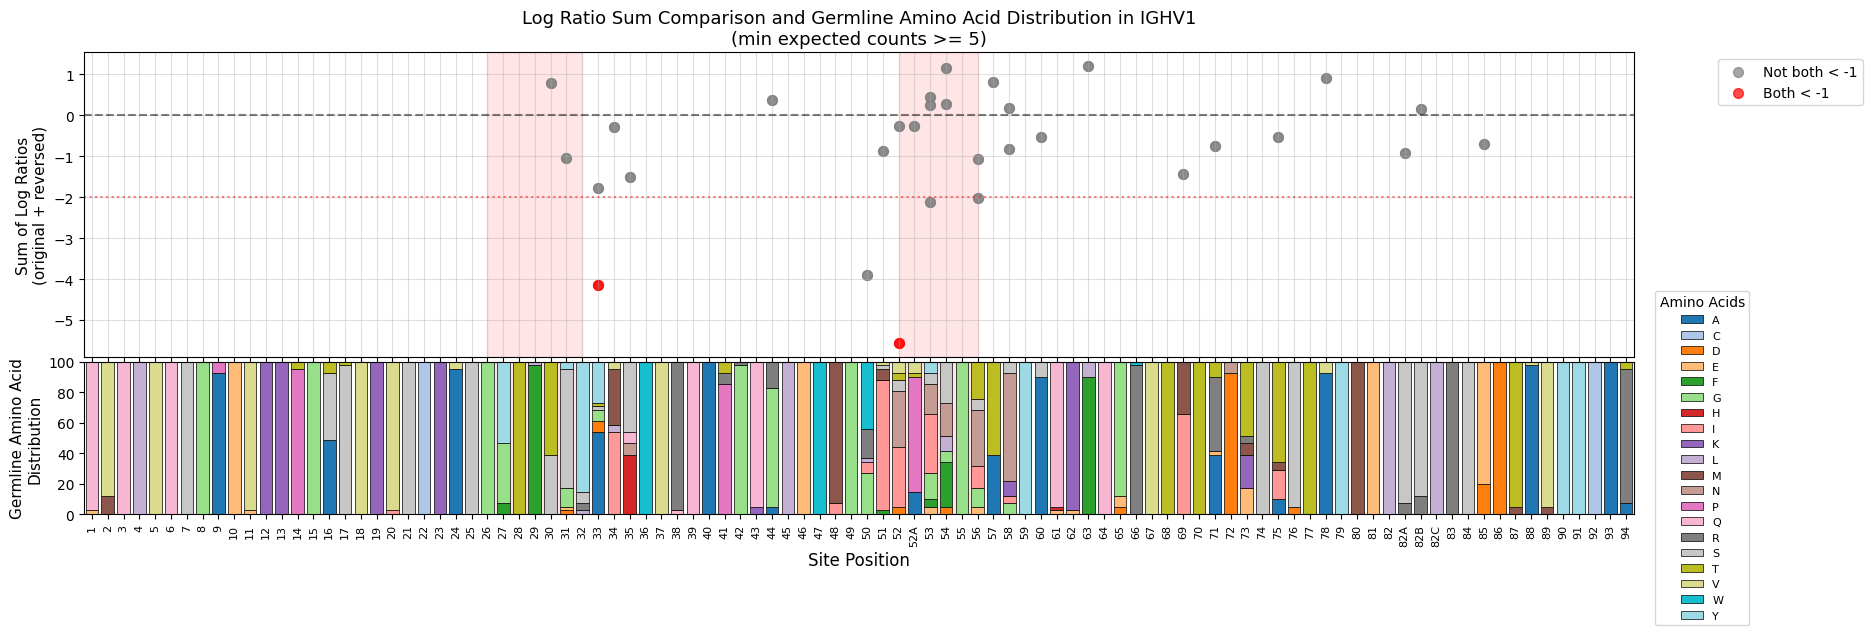

/loc/scratch/49383474/ipykernel_36236/1421534784.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


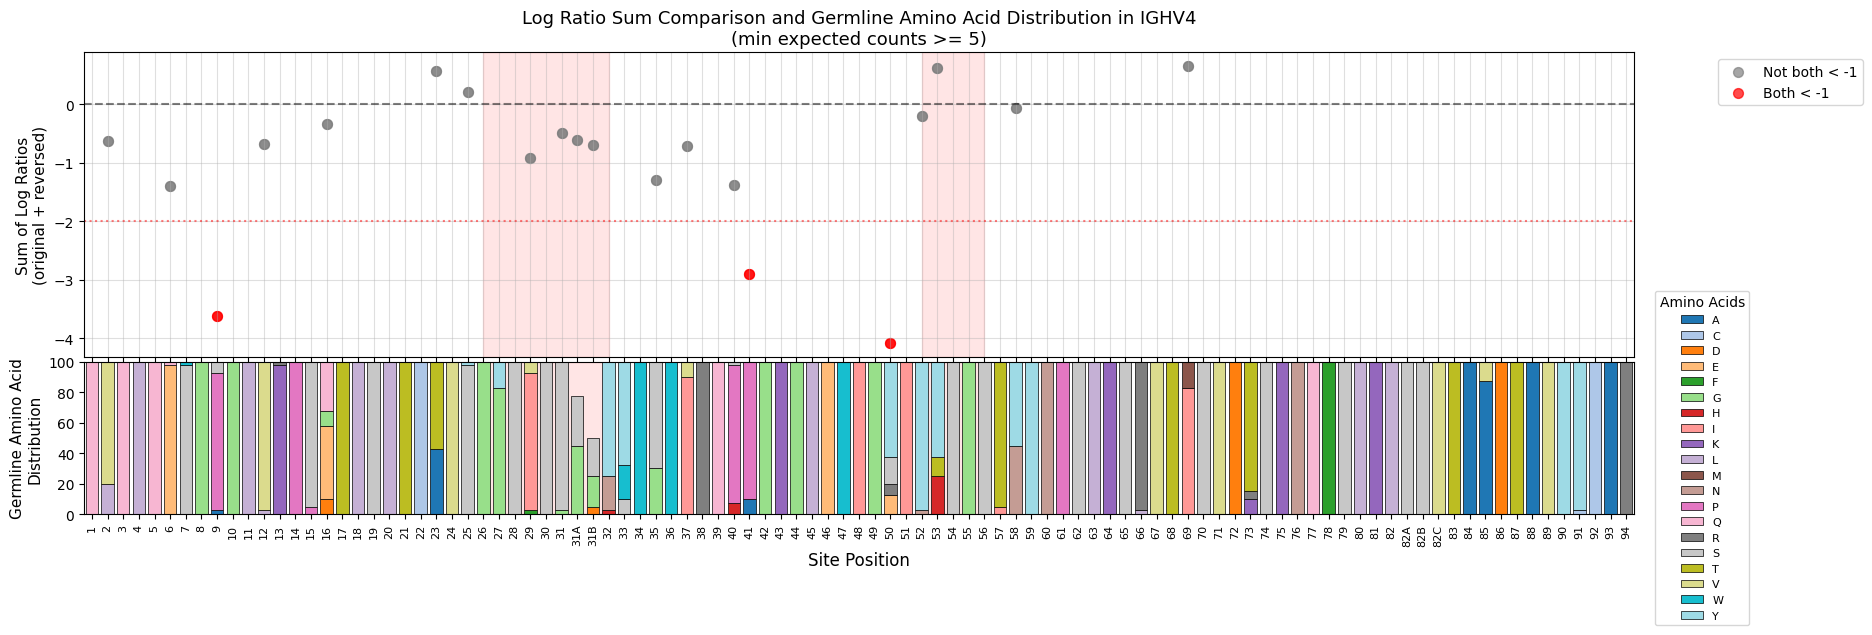

/loc/scratch/49383474/ipykernel_36236/1421534784.py:360: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


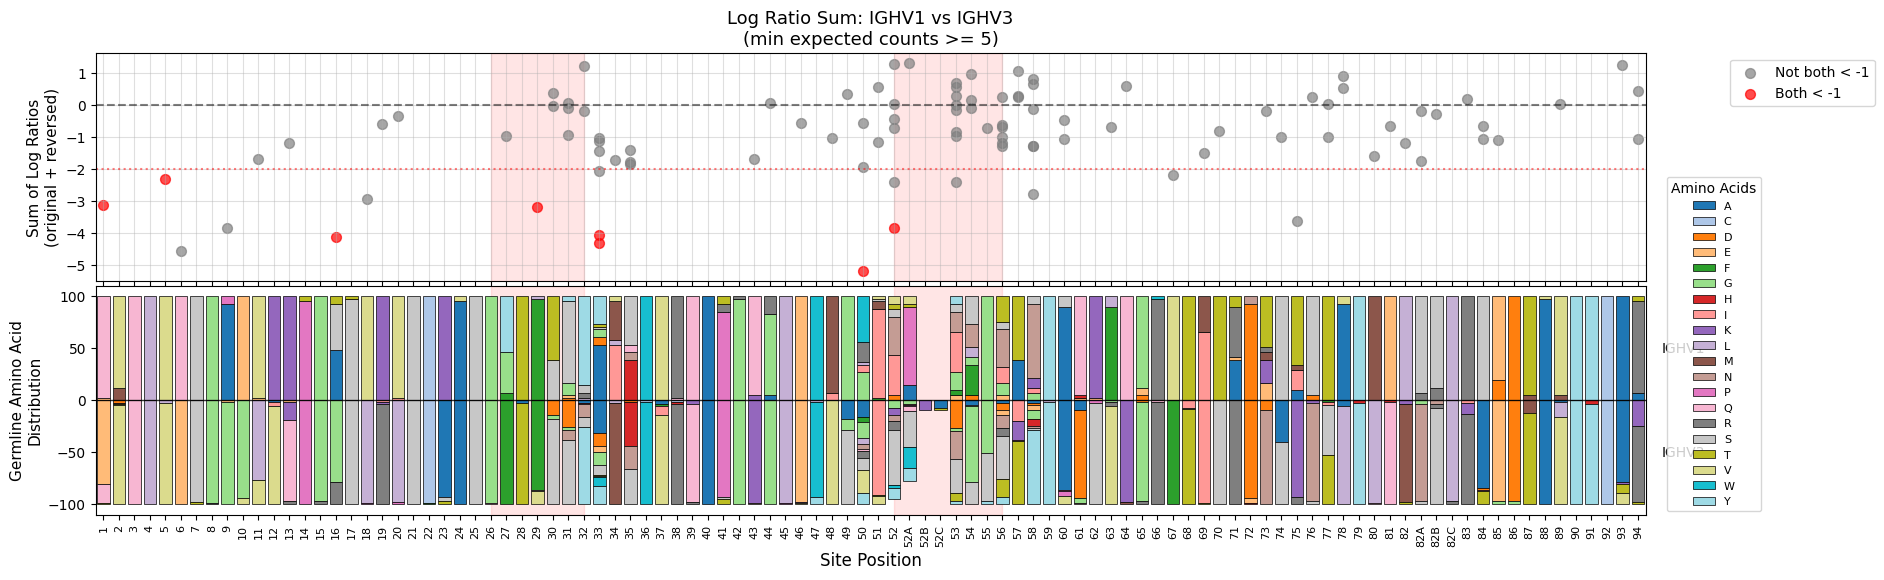

/loc/scratch/49383474/ipykernel_36236/1421534784.py:360: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


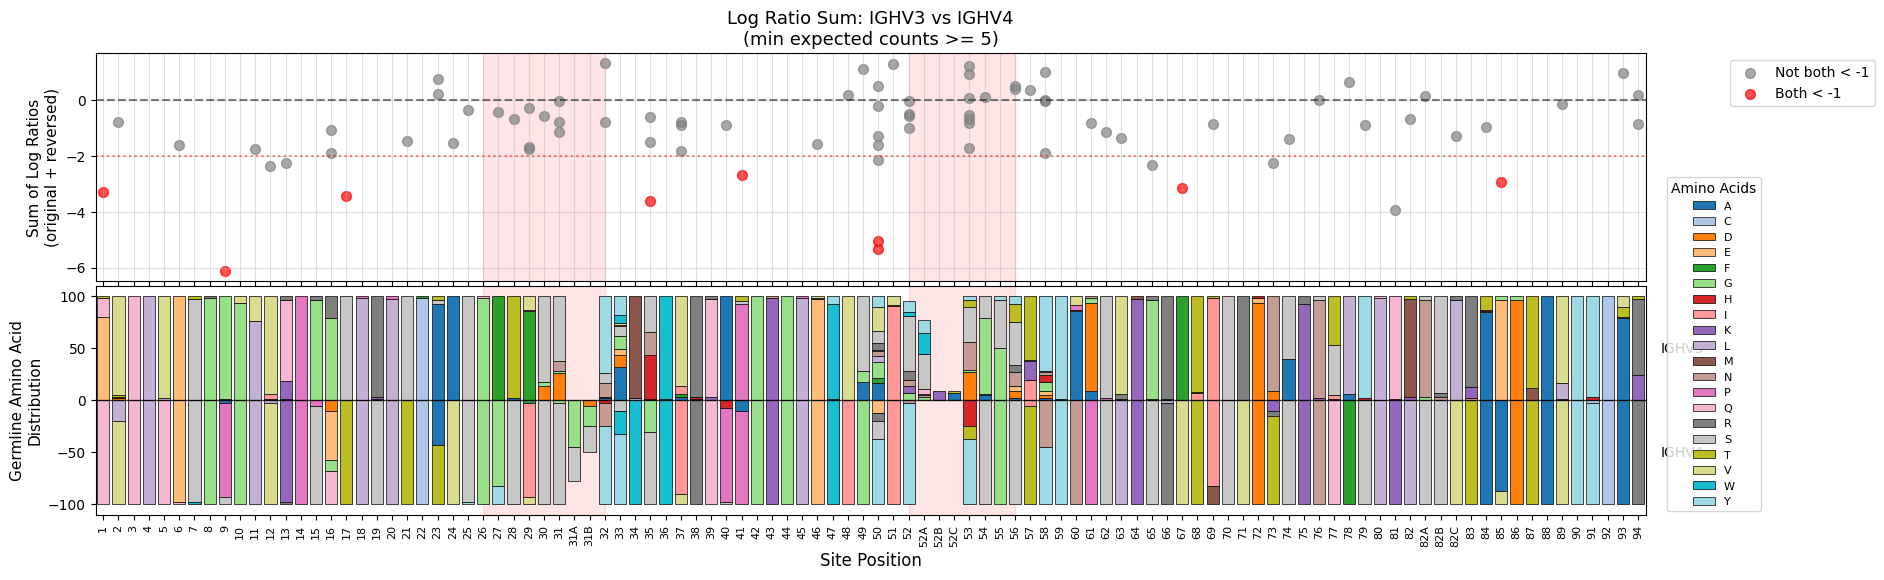

/loc/scratch/49383474/ipykernel_36236/1421534784.py:360: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


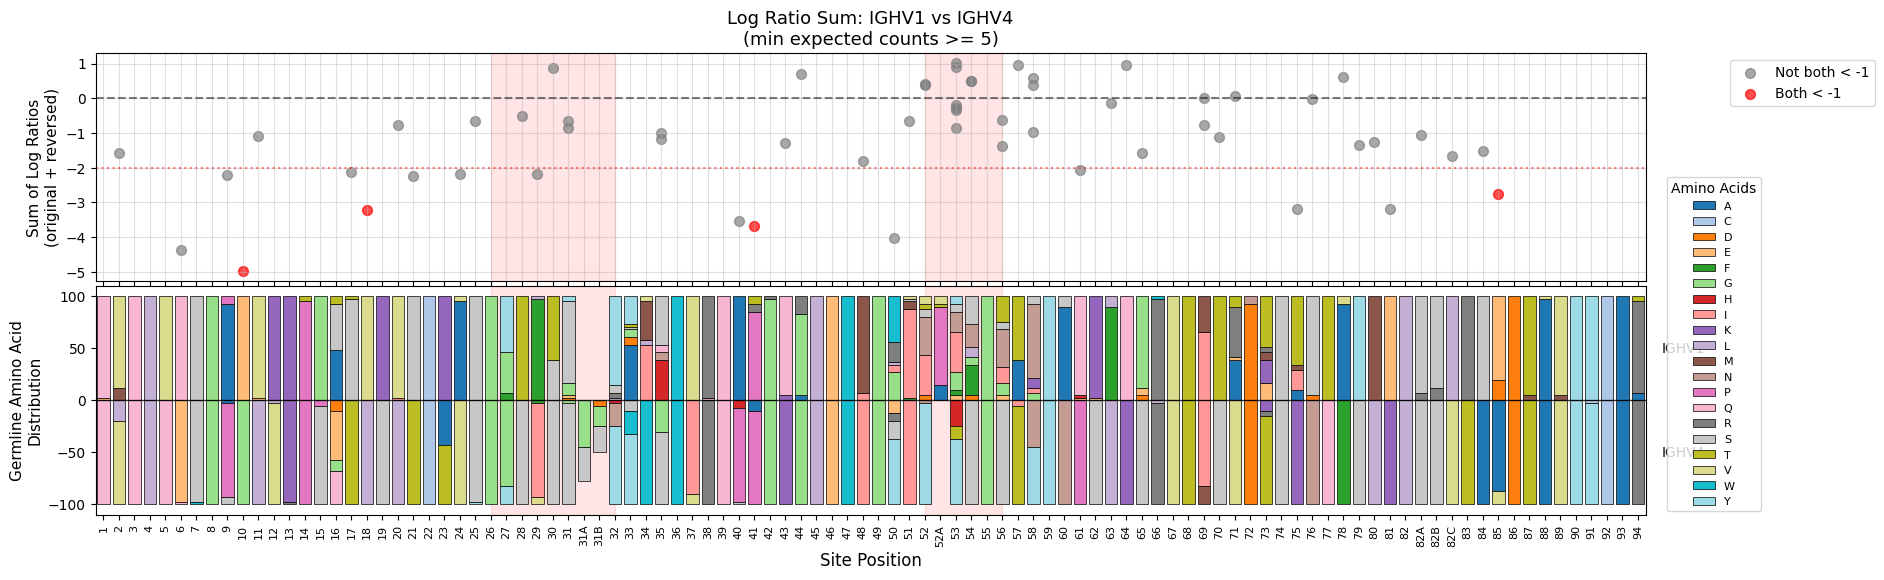

In [21]:

# Within v_family comparison
compare_df, fig, axes = compare_rates_within_vfamily_with_distribution(
    merge_counts, 
    germline_codons_df,
    v_family='IGHV3',
    numbering_scheme=numbering_scheme,
    min_expected_counts=5,
    threshold=-1
)

# Within v_family comparison
compare_df, fig, axes = compare_rates_within_vfamily_with_distribution(
    merge_counts, 
    germline_codons_df,
    v_family='IGHV1',
    numbering_scheme=numbering_scheme,
    min_expected_counts=5,
    threshold=-1
)

# Within v_family comparison
compare_df, fig, axes = compare_rates_within_vfamily_with_distribution(
    merge_counts, 
    germline_codons_df,
    v_family='IGHV4',
    numbering_scheme=numbering_scheme,
    min_expected_counts=5,
    threshold=-1
)

# Between v_families comparison
compare_df, fig, axes = compare_rates_between_vfamilies_with_distribution(
    merge_counts, 
    germline_codons_df,
    v_family1='IGHV1',
    v_family2='IGHV3',
    numbering_scheme=numbering_scheme,
    min_expected_counts=5,
    threshold=-1
)


# Between v_families comparison
compare_df, fig, axes = compare_rates_between_vfamilies_with_distribution(
    merge_counts, 
    germline_codons_df,
    v_family1='IGHV3',
    v_family2='IGHV4',
    numbering_scheme=numbering_scheme,
    min_expected_counts=5,
    threshold=-1
)

# Between v_families comparison
compare_df, fig, axes = compare_rates_between_vfamilies_with_distribution(
    merge_counts, 
    germline_codons_df,
    v_family1='IGHV1',
    v_family2='IGHV4',
    numbering_scheme=numbering_scheme,
    min_expected_counts=5,
    threshold=-1
)

In [22]:
temp_df[temp_df.site == '52'][['parent_aa', 'child_aa', 'expected_counts_original', 'expected_counts_reversed', 'observed_counts_original', 'observed_counts_reversed']]

,parent_aa,child_aa,expected_counts_original,expected_counts_reversed,observed_counts_original,observed_counts_reversed
332,I,S,6.016841,9.547685,0,0
333,I,S,6.016841,118.522265,0,33
334,K,N,206.635734,56.298041,379,20
335,K,N,206.635734,46.875019,379,57
336,K,N,206.635734,16.964166,379,3
337,K,R,123.841915,21.738319,144,28
338,N,K,56.298041,206.635734,20,379
339,N,S,93.976927,21.420934,56,28
340,N,S,93.976927,249.075298,56,208
341,N,Y,18.514624,11.398565,27,8


In [23]:
temp_df[(temp_df.site == '31') & (temp_df.log_ratio_original < -1) & (temp_df.log_ratio_reversed < -1)]

,site,parent_aa,v_family_original,child_aa,expected_counts_original,mutcount_length_observed_original,observed_counts_original,observed_counts_adjusted_original,ratio_original,log_ratio_original,v_family_reversed,expected_counts_reversed,mutcount_length_observed_reversed,observed_counts_reversed,observed_counts_adjusted_reversed,ratio_reversed,log_ratio_reversed,log_ratio_sum
